In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [5]:
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name.lower() == 'notebooks' else cwd

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
TABLES_DIR = PROJECT_ROOT / 'outputs' / 'tables'

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)


In [6]:
#Load database
model_path = PROCESSED_DIR / 'modelling_data.csv'

model_df = pd.read_csv(model_path)

model_df.head()

,settlement_date,settlement_period,from_uk_naive,forecast_gco2_per_kwh,actual_gco2_per_kwh,index,price_gbp_per_mwh
0,2026-06-22,1,2026-06-22 00:00:00,193,189,high,111.19
1,2026-06-22,2,2026-06-22 00:30:00,188,187,high,108.63
2,2026-06-22,3,2026-06-22 01:00:00,196,182,high,104.94
3,2026-06-22,4,2026-06-22 01:30:00,190,179,high,100.83
4,2026-06-22,5,2026-06-22 02:00:00,189,179,high,81.33


In [7]:
model_df.dtypes

settlement_date              str
settlement_period          int64
from_uk_naive                str
forecast_gco2_per_kwh      int64
actual_gco2_per_kwh        int64
index                        str
price_gbp_per_mwh        float64
dtype: object

In [8]:
model_df['settlement_date'] = pd.to_datetime(model_df['settlement_date'])
model_df['from_uk_naive'] = pd.to_datetime(model_df['from_uk_naive'])
model_df.dtypes

settlement_date          datetime64[us]
settlement_period                 int64
from_uk_naive            datetime64[us]
forecast_gco2_per_kwh             int64
actual_gco2_per_kwh               int64
index                               str
price_gbp_per_mwh               float64
dtype: object

In [9]:
model_df[['forecast_gco2_per_kwh','actual_gco2_per_kwh','price_gbp_per_mwh']].describe()

,forecast_gco2_per_kwh,actual_gco2_per_kwh,price_gbp_per_mwh
count,336.000000,336.000000,336.000000
mean,156.809524,158.229167,109.962945
std,55.085166,52.878835,100.117211
min,36.000000,41.000000,-85.660000
25%,117.000000,118.000000,78.645178
50%,168.000000,167.000000,95.710000
75%,202.250000,204.000000,125.410000
max,246.000000,243.000000,800.000000


In [10]:
#Correlation analysis - Pearson
pearson_corr = model_df[
    ['forecast_gco2_per_kwh','actual_gco2_per_kwh','price_gbp_per_mwh']
    ].corr(method='pearson')
pearson_corr
     

,forecast_gco2_per_kwh,actual_gco2_per_kwh,price_gbp_per_mwh
forecast_gco2_per_kwh,1.000000,0.957927,0.391851
actual_gco2_per_kwh,0.957927,1.000000,0.444309
price_gbp_per_mwh,0.391851,0.444309,1.000000


In [11]:
#Correlation analysis - Spearman
spear_corr = model_df[
    ['forecast_gco2_per_kwh','actual_gco2_per_kwh','price_gbp_per_mwh']
    ].corr(method='spearman')
spear_corr

,forecast_gco2_per_kwh,actual_gco2_per_kwh,price_gbp_per_mwh
forecast_gco2_per_kwh,1.000000,0.955763,0.460421
actual_gco2_per_kwh,0.955763,1.000000,0.526820
price_gbp_per_mwh,0.460421,0.526820,1.000000


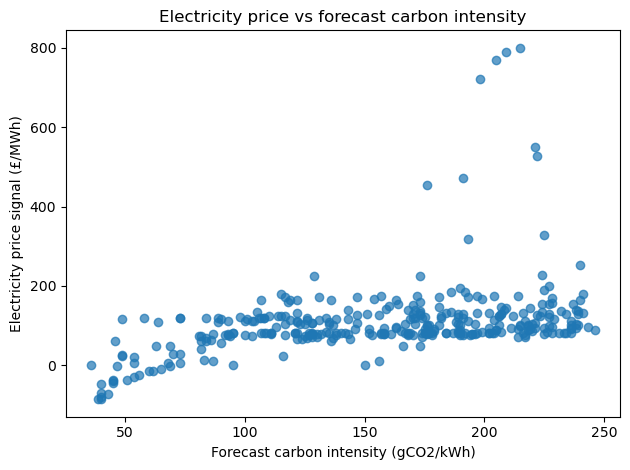

In [12]:
#plt.figure(figsize=(7, 5))

plt.scatter(
    model_df["forecast_gco2_per_kwh"],
    model_df["price_gbp_per_mwh"],
    alpha=0.7
)

plt.xlabel("Forecast carbon intensity (gCO2/kWh)")
plt.ylabel("Electricity price signal (£/MWh)")
plt.title("Electricity price vs forecast carbon intensity")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "price_vs_forecast_carbon.png", dpi=300)
plt.show()

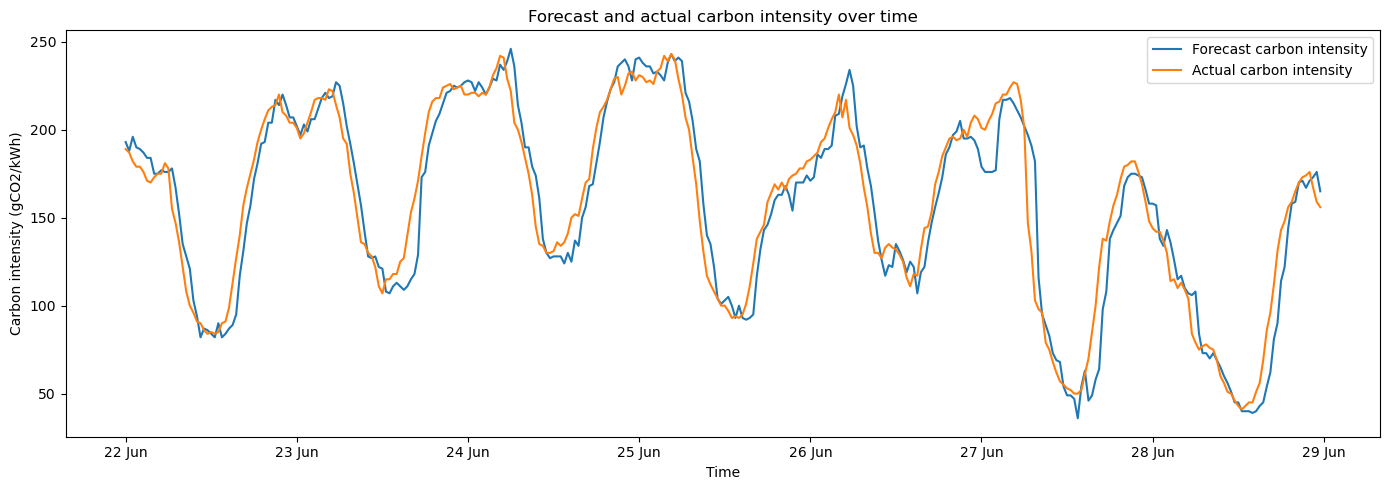

In [13]:
import matplotlib.dates as mdates #Plot of forecast vs actual intensity
plt.figure(figsize=(14, 5))

plt.plot(
    model_df["from_uk_naive"],
    model_df["forecast_gco2_per_kwh"],
    label="Forecast carbon intensity",
    linewidth=1.5
)

plt.plot(
    model_df["from_uk_naive"],
    model_df["actual_gco2_per_kwh"],
    label="Actual carbon intensity",
    linewidth=1.5
)

plt.xlabel("Time")
plt.ylabel("Carbon intensity (gCO2/kWh)")
plt.title("Forecast and actual carbon intensity over time")
plt.legend()
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.tight_layout()

plt.savefig(FIGURES_DIR / "carbon_intensity_timeseries.png", dpi=300)
plt.show()

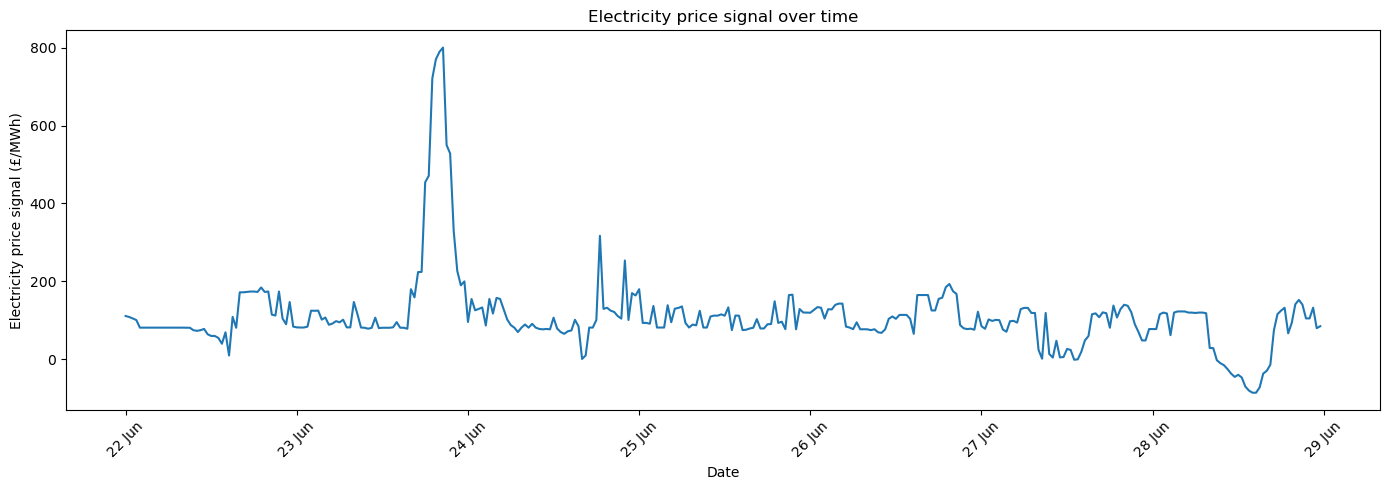

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    model_df["from_uk_naive"],
    model_df["price_gbp_per_mwh"],
    linewidth=1.5
)

ax.set_xlabel("Date")
ax.set_ylabel("Electricity price signal (£/MWh)")
ax.set_title("Electricity price signal over time")

ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.savefig(FIGURES_DIR / "price_timeseries.png", dpi=300)
plt.show()

In [16]:
model_df["forecast_error_gco2_per_kwh"] = (
    model_df["forecast_gco2_per_kwh"] - model_df["actual_gco2_per_kwh"]
)

model_df["absolute_forecast_error_gco2_per_kwh"] = (
    model_df["forecast_error_gco2_per_kwh"].abs()
)

model_df["percentage_forecast_error"] = np.where(
    model_df["actual_gco2_per_kwh"] != 0,
    (model_df["forecast_error_gco2_per_kwh"] / model_df["actual_gco2_per_kwh"]) * 100,
    np.nan
)

model_df["absolute_percentage_forecast_error"] = (
    model_df["percentage_forecast_error"].abs()
)
#Errors in the forecast against absolute

In [17]:
mae = model_df["absolute_forecast_error_gco2_per_kwh"].mean()

rmse = np.sqrt(
    (model_df["forecast_error_gco2_per_kwh"] ** 2).mean()
)

mbe = model_df["forecast_error_gco2_per_kwh"].mean()

mape = model_df["absolute_percentage_forecast_error"].mean()

nmae = (
    mae / model_df["actual_gco2_per_kwh"].mean()
) * 100

forecast_metrics = pd.DataFrame({
    "Metric": [
        "Mean bias error",
        "Mean absolute error",
        "Root mean squared error",
        "Mean absolute percentage error",
        "Normalised mean absolute error"
    ],
    "Value": [
        mbe,
        mae,
        rmse,
        mape,
        nmae
    ],
    "Unit": [
        "gCO2/kWh",
        "gCO2/kWh",
        "gCO2/kWh",
        "%",
        "%"
    ]
})

forecast_metrics

,Metric,Value,Unit
0,Mean bias error,-1.419643,gCO2/kWh
1,Mean absolute error,11.604167,gCO2/kWh
2,Root mean squared error,15.850586,gCO2/kWh
3,Mean absolute percentage error,8.399574,%
4,Normalised mean absolute error,7.333772,%


## Stopping point — 04 Exploratory Analysis

Completed:
- Loaded the joined modelling dataset.
- Plotted forecast and actual carbon intensity over the week.
- Checked price and carbon intensity relationship using Pearson/Spearman correlation.
- Started forecast error analysis using raw and normalised error.

Key finding so far:
- Forecast and actual carbon intensity broadly follow similar patterns.
- Price and carbon intensity appear [weakly positive / weakly negative / close to zero] over the selected week.
- Forecast error should be assessed using both raw error in gCO2/kWh and normalised percentage error.